In [1]:
import pandas as pd
from tower_eval.utils import read_lines, load_json_file, load_jsonl_file
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import RocCurveDisplay

In [2]:
def make_df(dataset, lp, model, context_postfix, oracle_metric):
    df = pd.DataFrame()
    raw_data = pd.read_json(f"raw_data/mt/{dataset}.{lp}/test.jsonl", lines=True)
    df["src"] = raw_data["src"].tolist()
    df["ref"] = raw_data["ref"].tolist()
    segment_ids = []
    seen_segments = 0
    for _, gr_df in raw_data.groupby("doc_id"):
        segment_ids.extend(list(range(seen_segments, len(gr_df) + seen_segments)))
        seen_segments += len(gr_df)
    df["seg_id"] = segment_ids
    context_settings = ["no_context", "full_context"]
    for c in context_settings:
        df[f"{c}_generation"] = read_lines(
            f"generations/{c}{context_postfix}/mt/{dataset}.{lp}/vllm/{model}/generation.txt"
        )
        df[f"{c}_{oracle_metric}"] = load_json_file(
            f"evaluations/{c}{context_postfix}/mt/{dataset}.{lp}/vllm/{model}/evaluation.json"
        )[f"{oracle_metric}_segments"]
        if c == context_settings[-1]:
            df[f"oracle_{oracle_metric}"] = df.apply(
                lambda x: (
                    x[f"no_context_{oracle_metric}"]
                    if x[f"full_context_{oracle_metric}"]
                    < x[f"no_context_{oracle_metric}"]
                    else x[f"full_context_{oracle_metric}"]
                ),
                axis=1,
            )
        for tgt in ["ref", "hyp", "src"]:
            df[f"{c}_{tgt}_mean_log_probs"] = [
                float(logprob)
                for logprob in read_lines(
                    f"pcxmi/{c}{context_postfix}/mt/{dataset}.{lp}/{model}/mean_log_probs_{tgt}.txt"
                )
            ]
            if c == context_settings[-1]:
                df[f"pcxmi_{tgt}"] = (
                    df[f"full_context_{tgt}_mean_log_probs"]
                    - df[f"no_context_{tgt}_mean_log_probs"]
                )
                if tgt == "src":
                    # pcxmi hyp may be high because the source may be surprising for no_context (and therefore the hyp)
                    # and full_context helps reduce surprise of source. We normalize by source to try to isolate the effect of context on the hypothesis.
                    df["pcxmi_src_inv"] = -df["pcxmi_src"]
                    df["pcxmi_hyp_norm_src"] = df["pcxmi_hyp"] / df["pcxmi_src"]
                    # df["pcxmi_hyp_norm_src_no_context"] = -(
                    #     df["pcxmi_hyp"] / df["no_context_src_mean_log_probs"]
                    # )
                    # df["pcxmi_hyp_norm_src_full_context"] = -(
                    #     df["pcxmi_hyp"] / df["full_context_src_mean_log_probs"]
                    # )
    df["binary_context_helped"] = (
        df[f"full_context_{oracle_metric}"] > df[f"no_context_{oracle_metric}"]
    ).astype(int)
    df["context_helped"] = df.apply(
        lambda x: (
            0
            if x[f"full_context_{oracle_metric}"] < x[f"no_context_{oracle_metric}"]
            else (
                1
                if x[f"full_context_{oracle_metric}"] > x[f"no_context_{oracle_metric}"]
                else 2
            )
        ),
        axis=1,
    )
    df[df.isna()] = 1.0
    df = df.replace([np.inf, -np.inf], 1.0)

    return df


def make_roc_plot(df, estimators):
    fig, ax = plt.subplots()
    ax.plot([0, 1], [0, 1], linestyle="--", c="gray", alpha=0.3)
    roc_obj = RocCurveDisplay
    for estimator_name in estimators:
        roc_obj.from_predictions(
            df["binary_context_helped"],
            df[f"pcxmi_{estimator_name}"],
            ax=ax,
            name=f"{estimator_name}",
        )
    plt.title("Predictive power of PCXMI flavors on context usefulness")
    sns.move_legend(
        ax,
        bbox_to_anchor=(0.5, -0.4),
        loc="lower center",
        ncols=round(len(estimators) / 2),
    )
    plt.show()


def make_roc_plot_with_orig(df, estimators, df_orig):
    fig, ax = plt.subplots()
    ax.plot([0, 1], [0, 1], linestyle="--", c="gray", alpha=0.3)
    roc_obj = RocCurveDisplay
    for estimator_name in estimators:
        roc_obj.from_predictions(
            df["binary_context_helped"],
            df[f"pcxmi_{estimator_name}"],
            ax=ax,
            name=f"{estimator_name}",
        )
    roc_obj.from_predictions(
        df_orig["binary_context_helped"],
        df_orig[f"pcxmi_hyp"],
        ax=ax,
        name="Full dataset",
        c="gray",
        alpha=0.2,
    )
    plt.title("Predictive power of PCXMI flavors on context usefulness")
    sns.move_legend(
        ax,
        bbox_to_anchor=(0.5, -0.4),
        loc="lower center",
        ncols=round((len(estimators) + 1) / 2),
    )
    plt.show()

In [3]:
dataset = "wmt24_chat_dev"
model = "TowerInstruct-7B-w-chat-empty-sys"
context_postfix = "_empty_sys"
oracle_metric = "comet"
estimators = [
    "ref",
    "hyp",
    "src_inv",
    "hyp_norm_src",
    # "hyp_norm_src_no_context",
    # "hyp_norm_src_full_context",
]
lps = [f"en-{xx}" for xx in ["de", "fr", "nl", "pt-br", "ko"]] + [
    f"{xx}-en" for xx in ["de", "fr", "nl", "pt-br", "ko"]
]

EN-DE


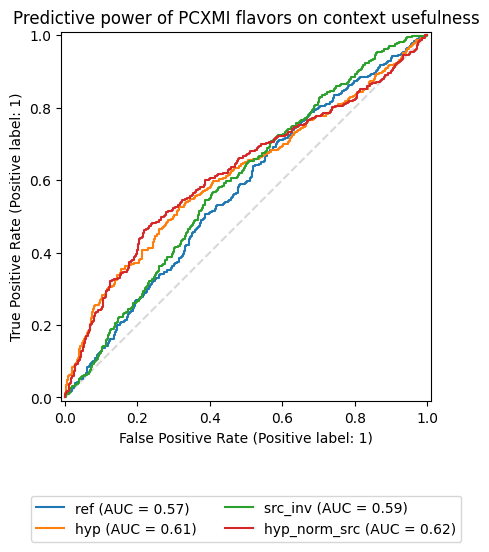

EN-FR


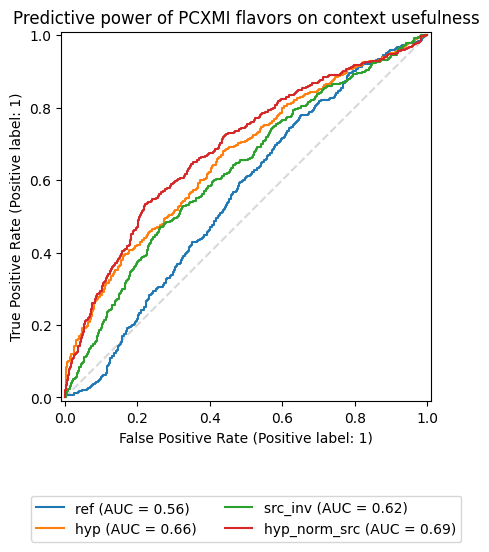

EN-NL


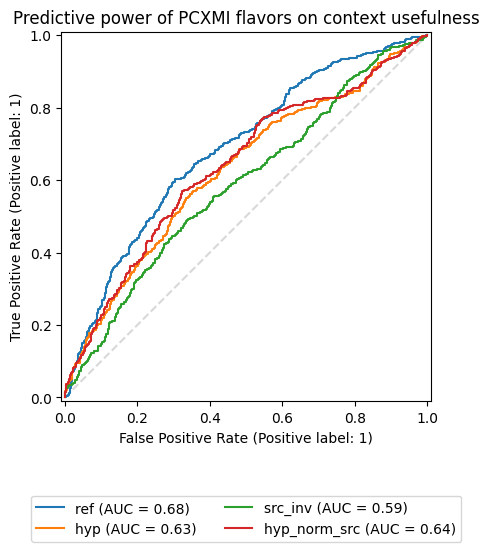

EN-PT-BR


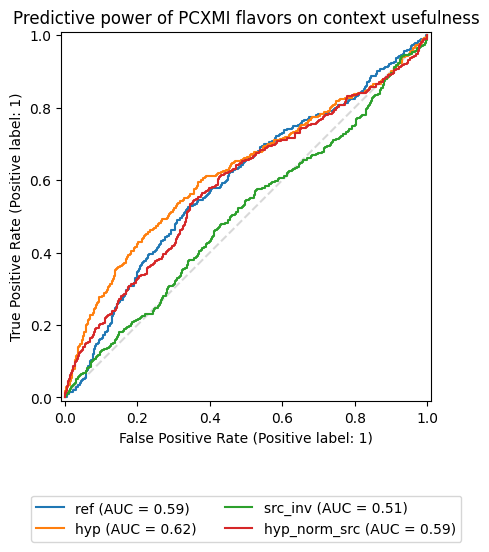

EN-KO


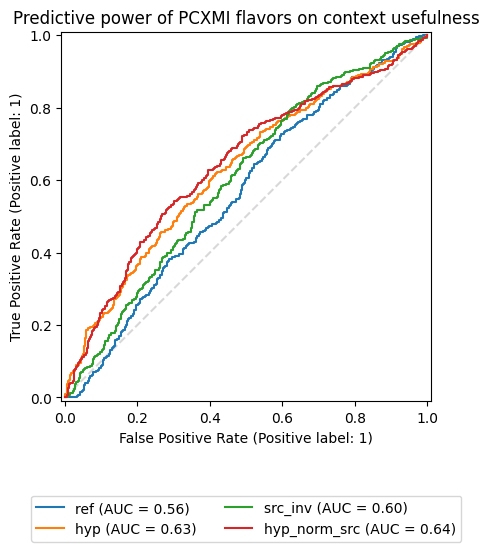

DE-EN


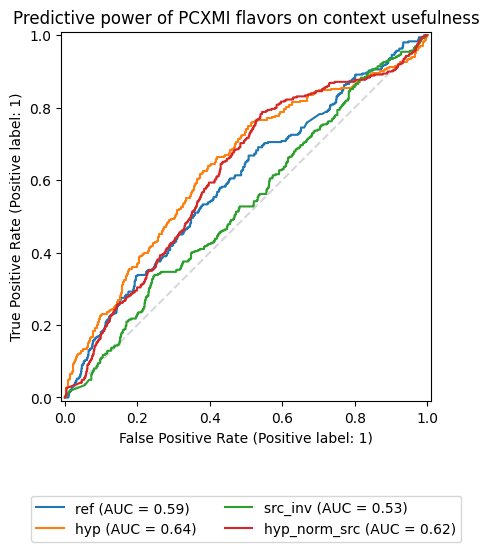

FR-EN


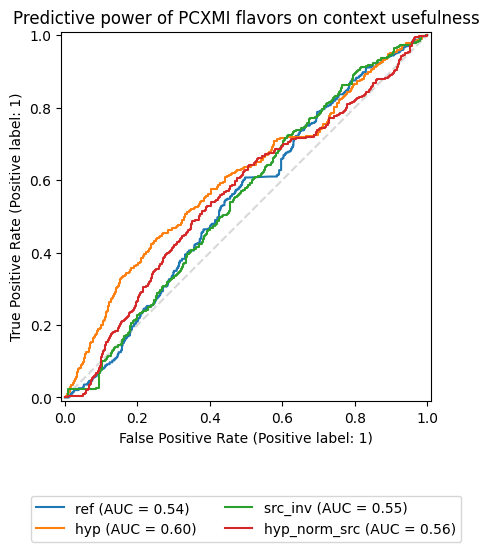

NL-EN


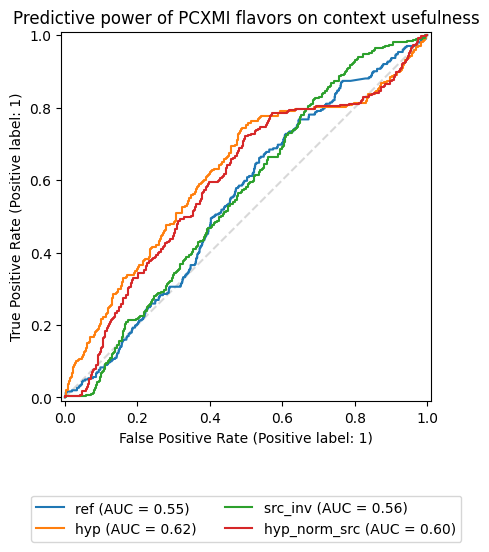

PT-BR-EN


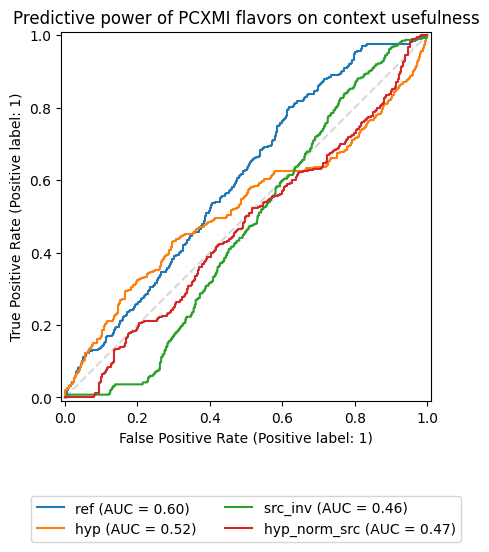

KO-EN


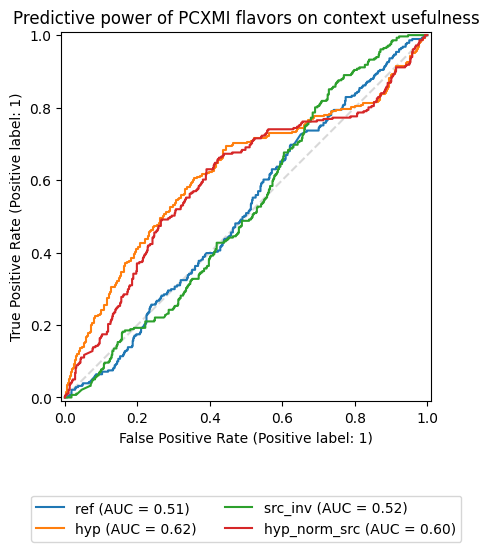

In [4]:
for lp in lps:
    df = make_df(dataset, lp, model, context_postfix, oracle_metric)
    print(lp.upper())
    make_roc_plot(df, estimators)

# Plots on sliced data

### Low quality buckets

EN-DE


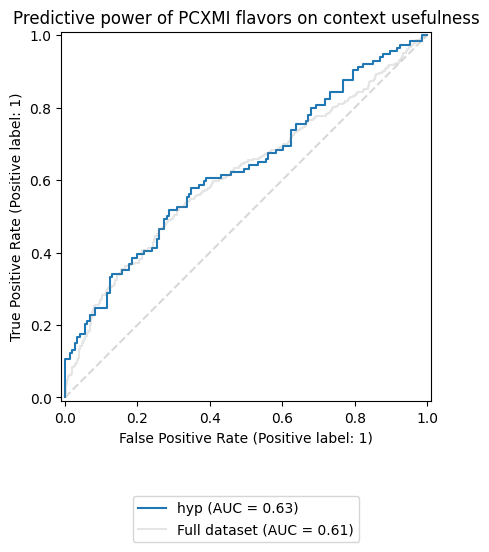

EN-FR


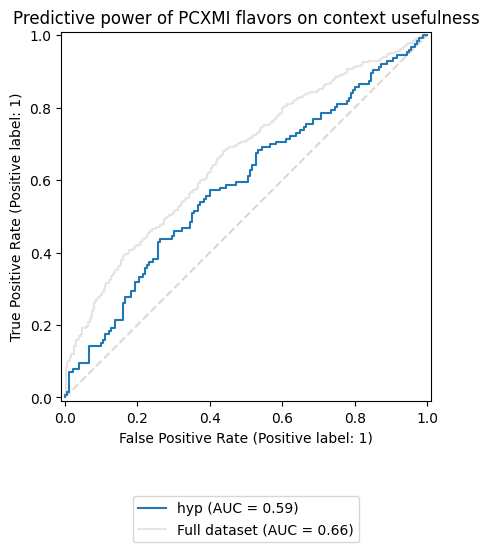

EN-NL


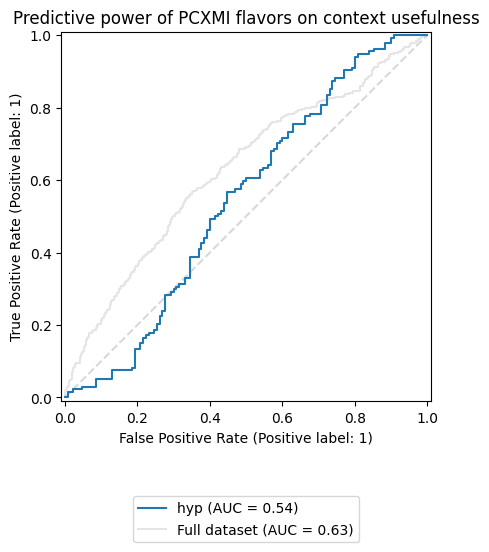

EN-PT-BR


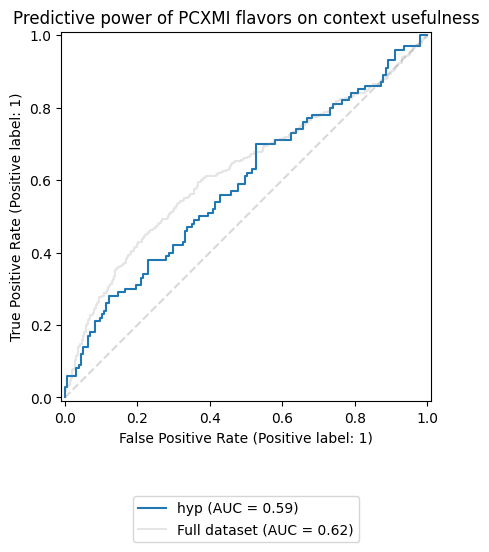

EN-KO


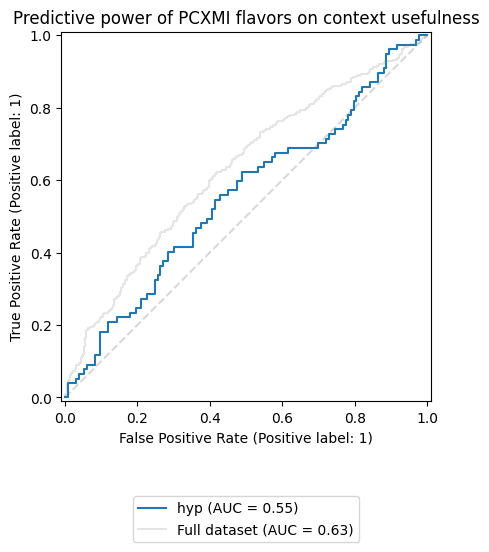

DE-EN


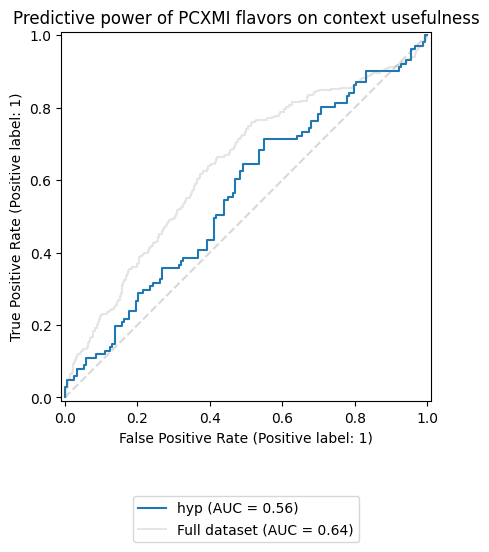

FR-EN


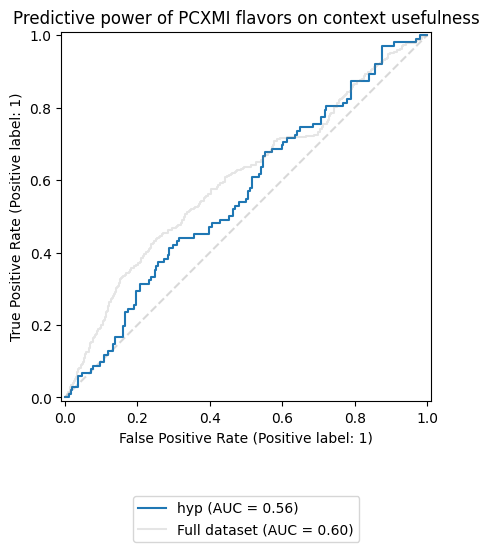

NL-EN


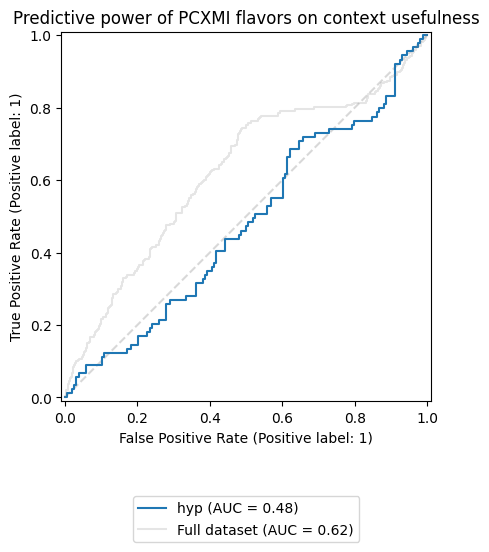

PT-BR-EN


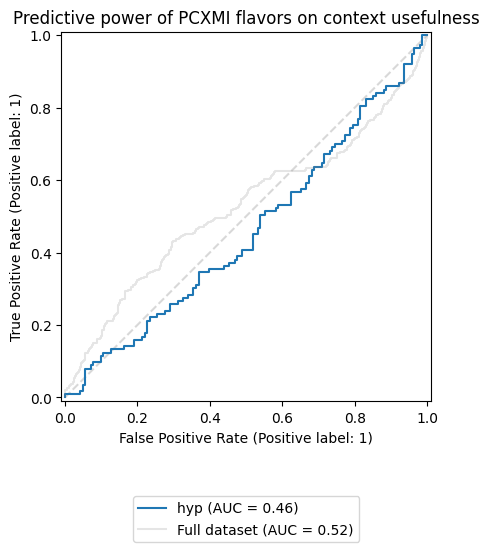

KO-EN


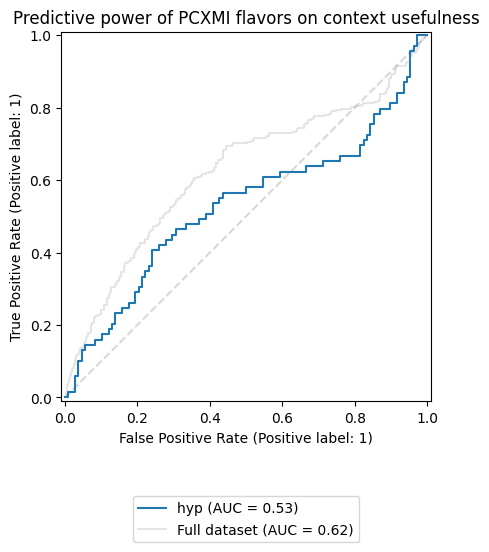

In [5]:
estimators = [
    "hyp",
]
quantile = 0.20
for lp in lps:
    df = make_df(dataset, lp, model, context_postfix, oracle_metric)
    df_subset = df[
        df[f"oracle_{oracle_metric}"] < df[f"oracle_{oracle_metric}"].quantile(quantile)
    ]
    print(lp.upper())
    make_roc_plot_with_orig(df_subset, estimators, df)

### High quality buckets

EN-DE


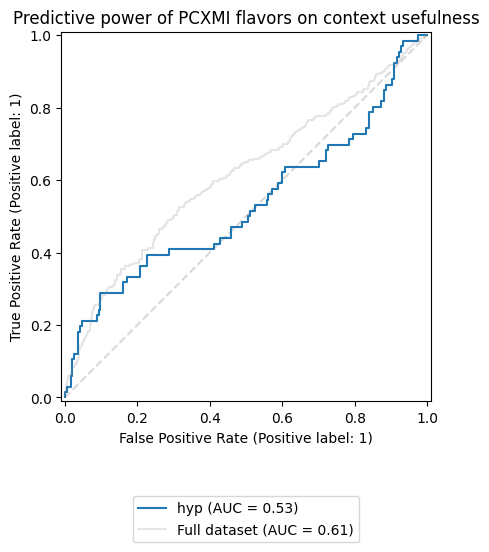

EN-FR


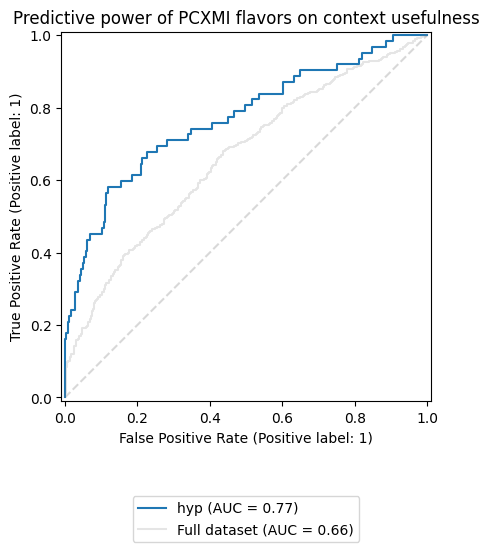

EN-NL


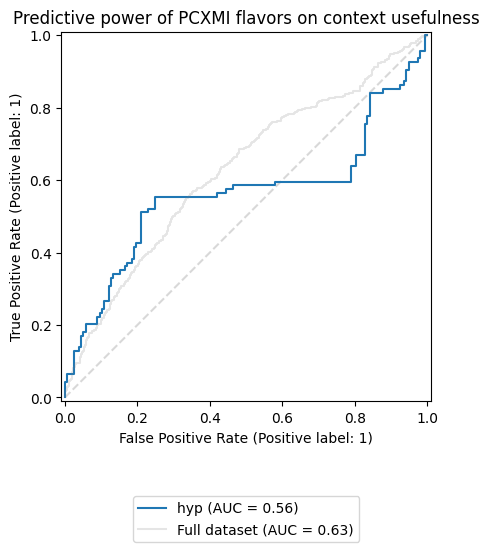

EN-PT-BR


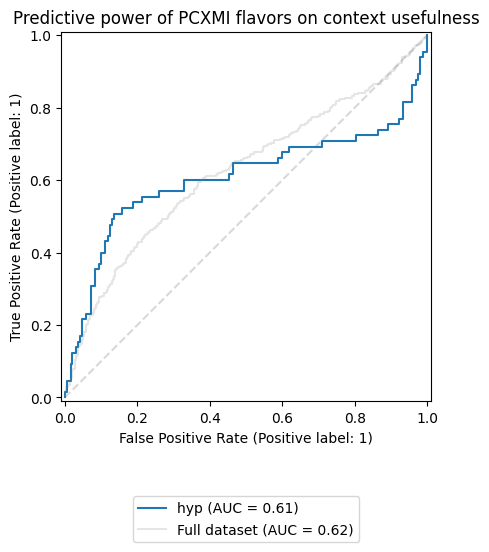

EN-KO


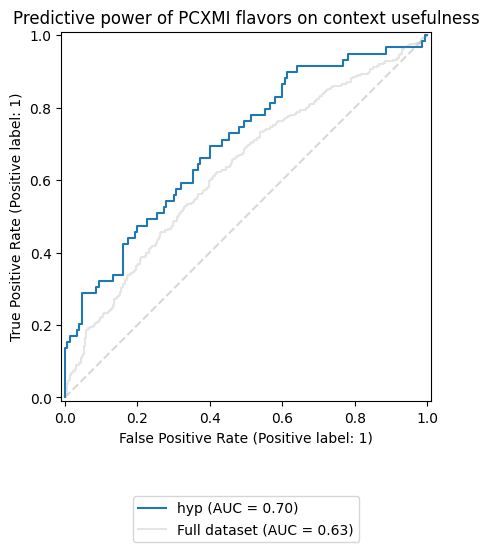

DE-EN


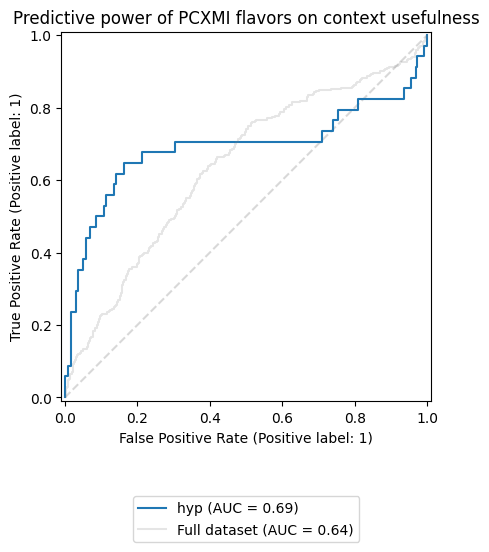

FR-EN


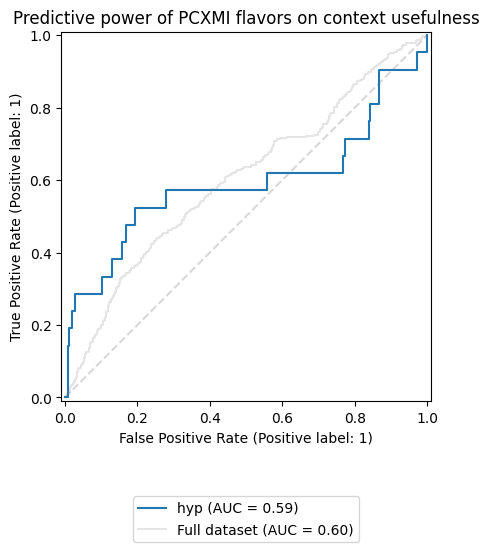

NL-EN


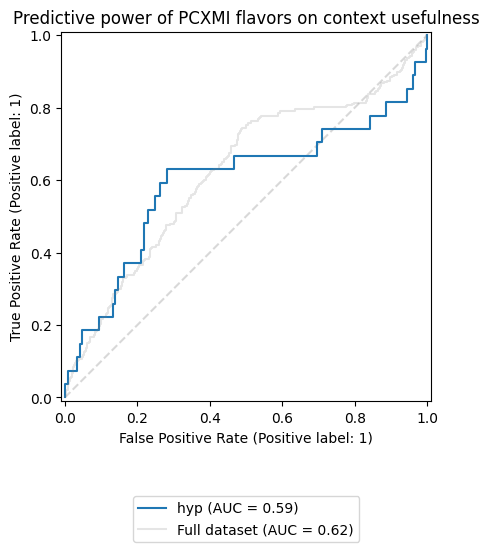

PT-BR-EN


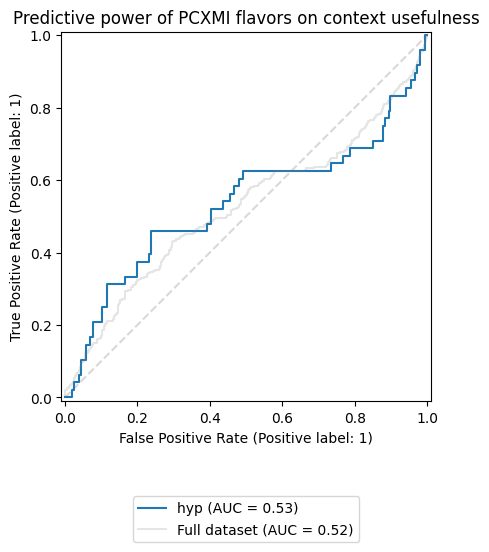

KO-EN


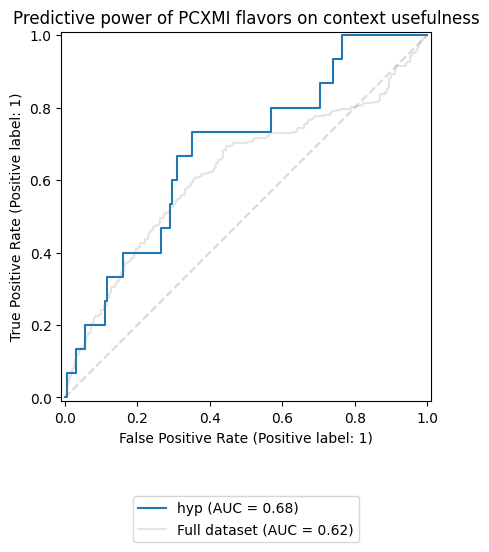

In [6]:
estimators = [
    "hyp",
]
quantile = 0.80
for lp in lps:
    df = make_df(dataset, lp, model, context_postfix, oracle_metric)
    df_subset = df[
        df[f"oracle_{oracle_metric}"] > df[f"oracle_{oracle_metric}"].quantile(quantile)
    ]
    print(lp.upper())
    make_roc_plot_with_orig(df_subset, estimators, df)

### Larger sources

EN-DE


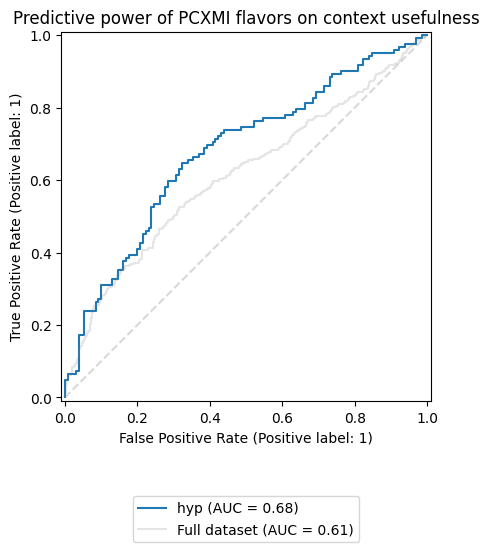

EN-FR


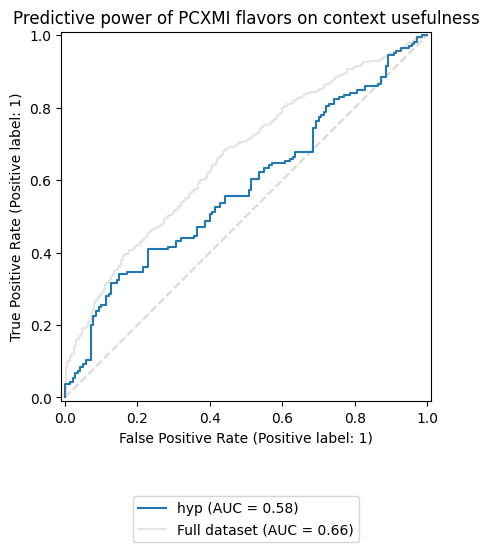

EN-NL


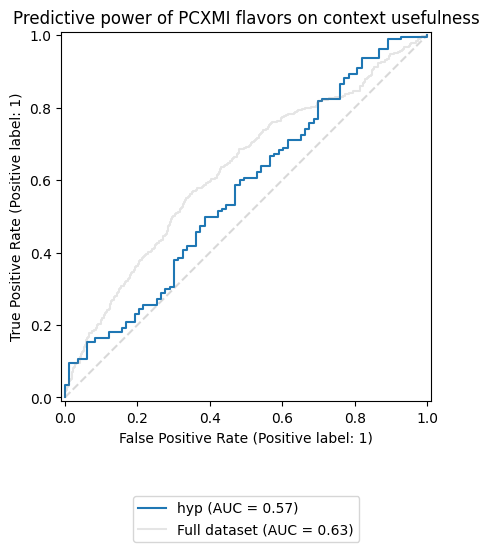

EN-PT-BR


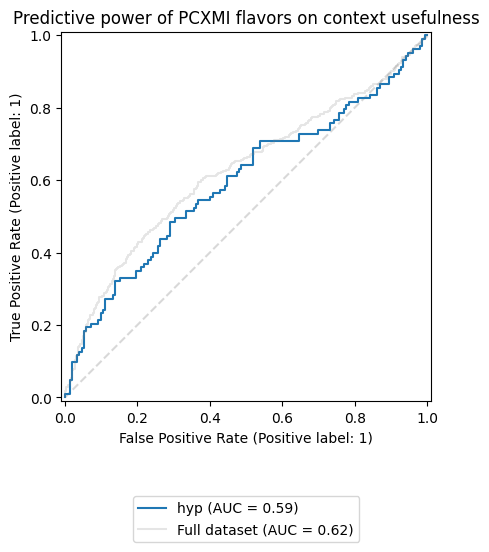

EN-KO


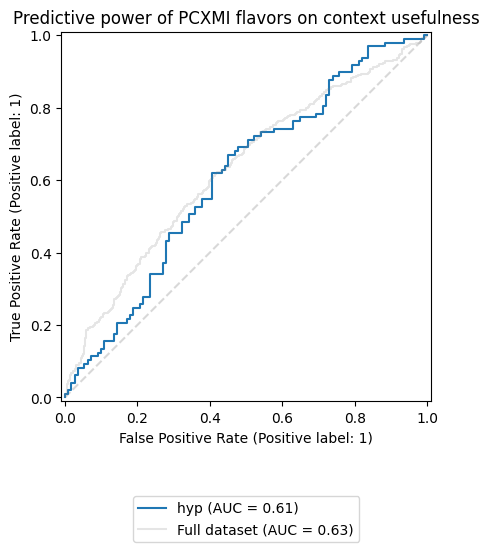

DE-EN


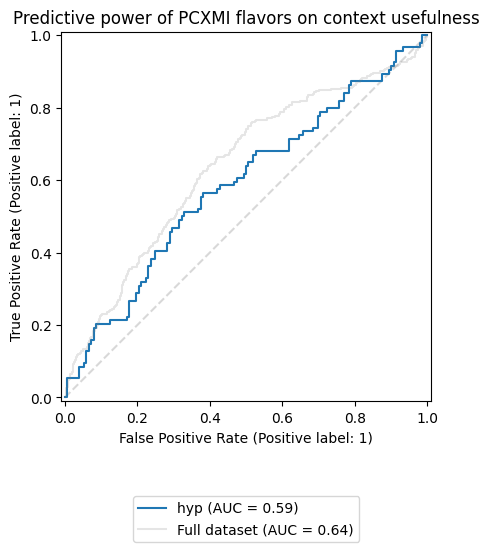

FR-EN


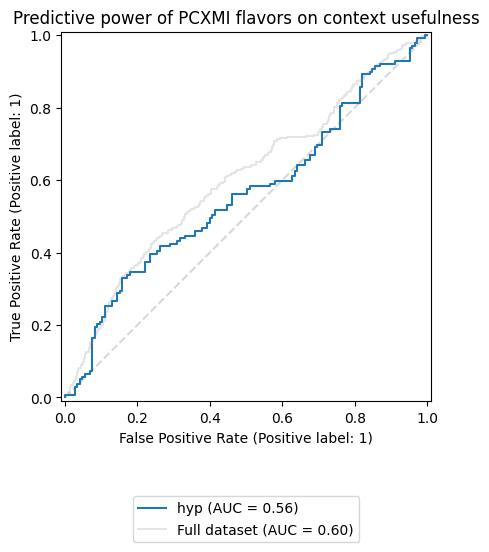

NL-EN


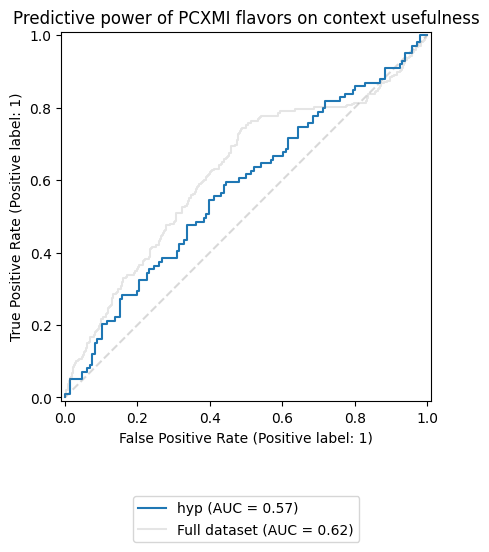

PT-BR-EN


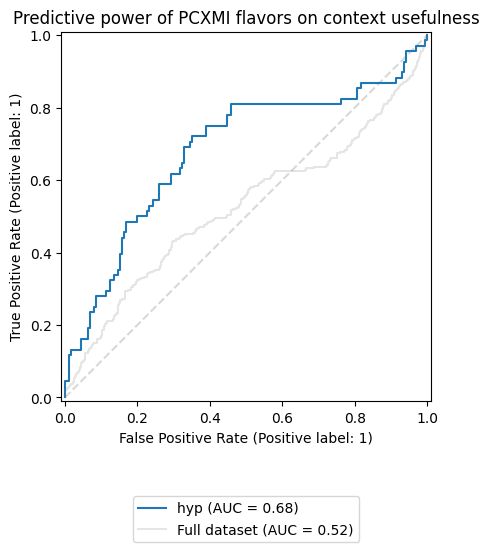

KO-EN


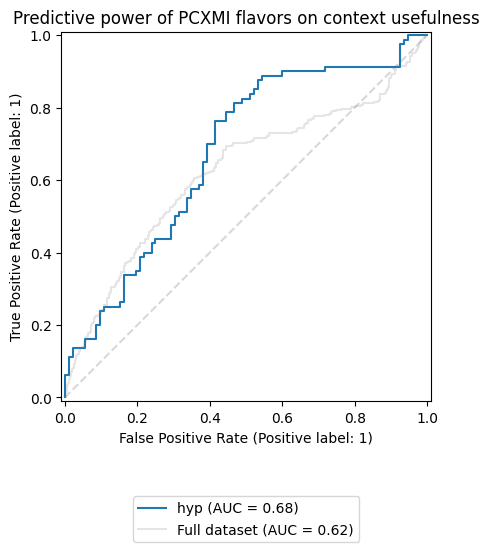

In [7]:
estimators = [
    "hyp",
]
quantile = 0.80
for lp in lps:
    df = make_df(dataset, lp, model, context_postfix, oracle_metric)
    df["src_len"] = df["src"].apply(len)
    df_subset = df[df["src_len"] > df["src_len"].quantile(quantile)]
    print(lp.upper())
    make_roc_plot_with_orig(df_subset, estimators, df)

### Smaller sources

EN-DE


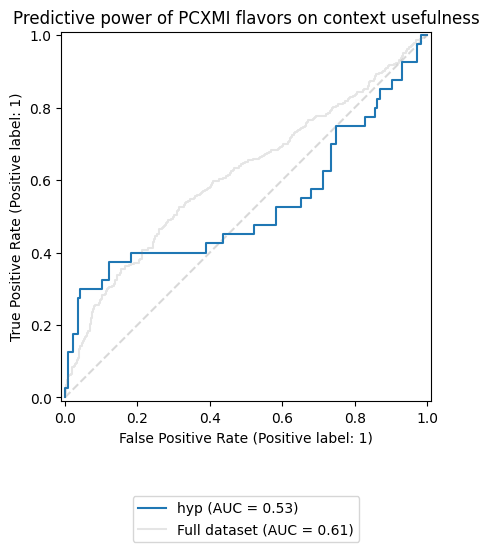

EN-FR


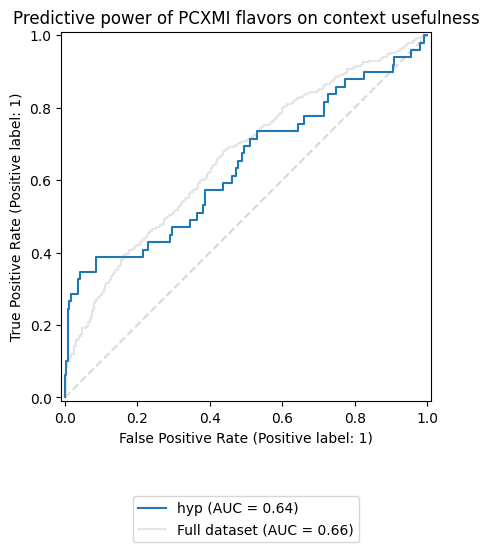

EN-NL


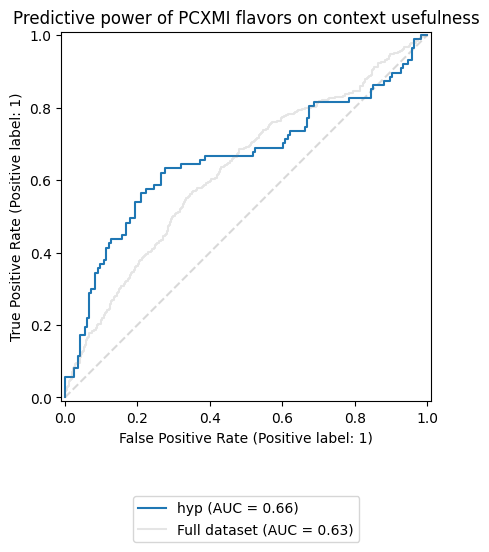

EN-PT-BR


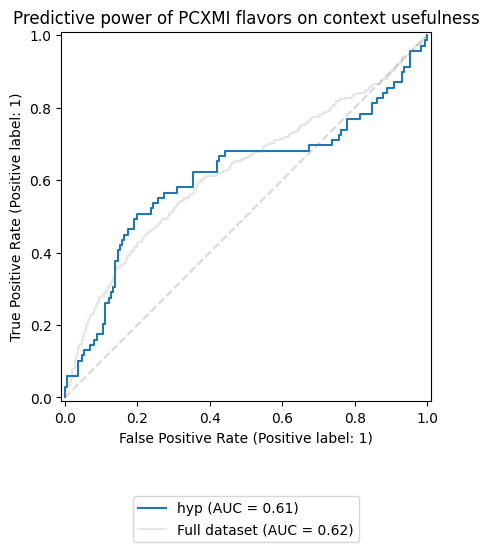

EN-KO


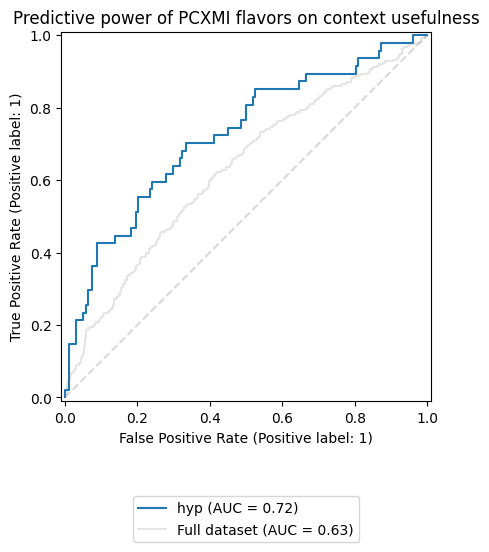

DE-EN


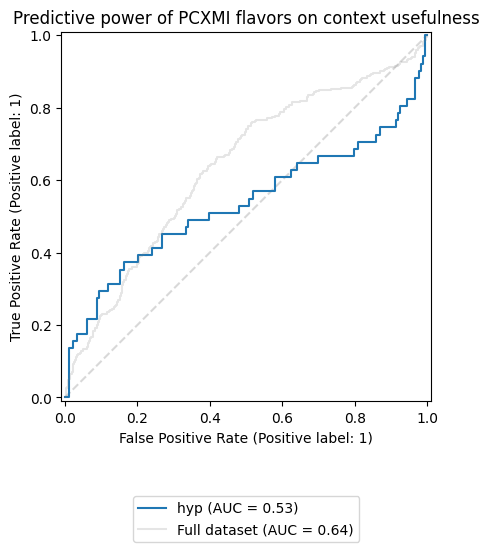

FR-EN


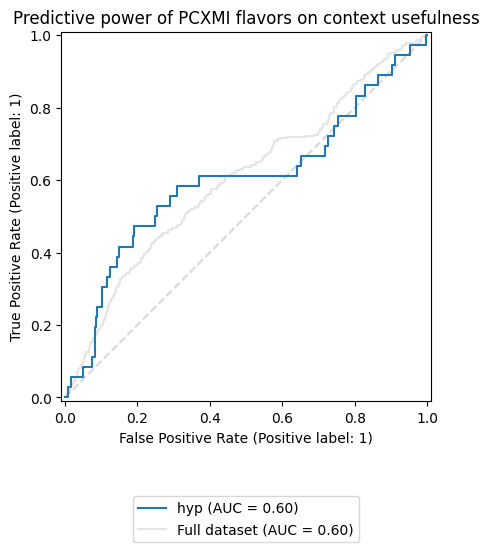

NL-EN


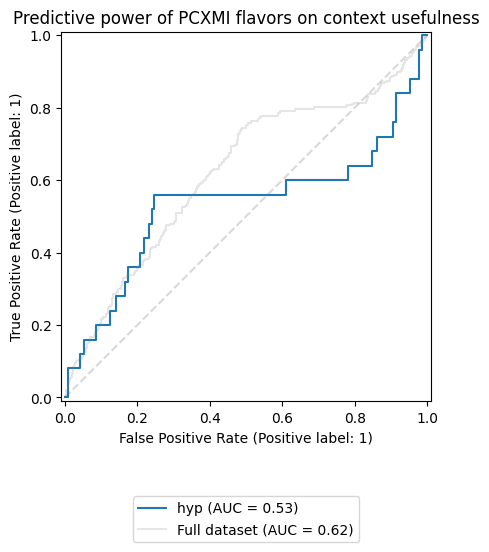

PT-BR-EN


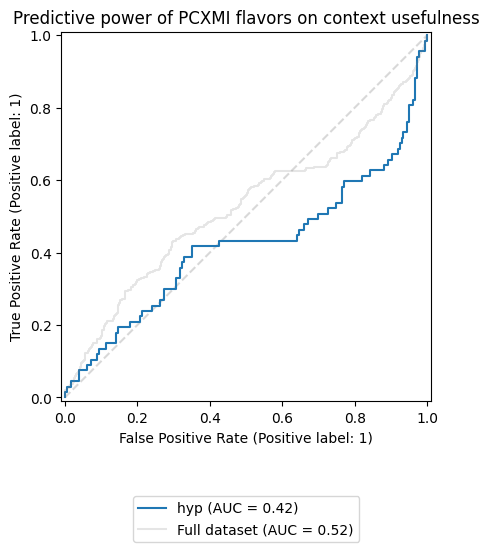

KO-EN


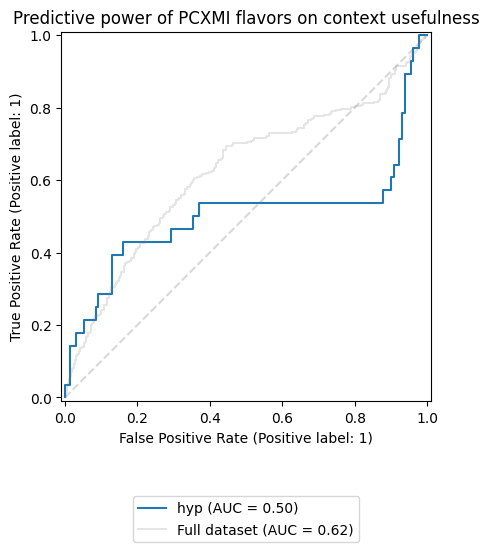

In [8]:
estimators = [
    "hyp",
]
quantile = 0.20
for lp in lps:
    df = make_df(dataset, lp, model, context_postfix, oracle_metric)
    df["src_len"] = df["src"].apply(len)
    df_subset = df[df["src_len"] < df["src_len"].quantile(quantile)]
    print(lp.upper())
    make_roc_plot_with_orig(df_subset, estimators, df)

# Later turns in conversation

EN-DE


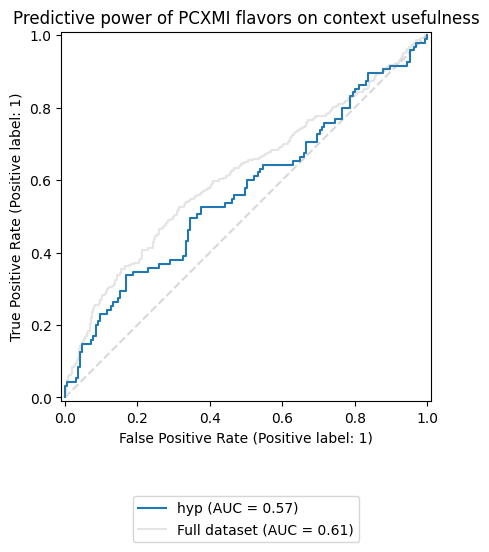

EN-FR


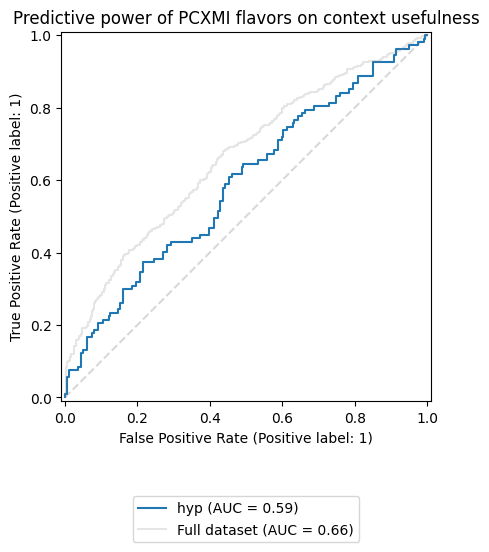

EN-NL


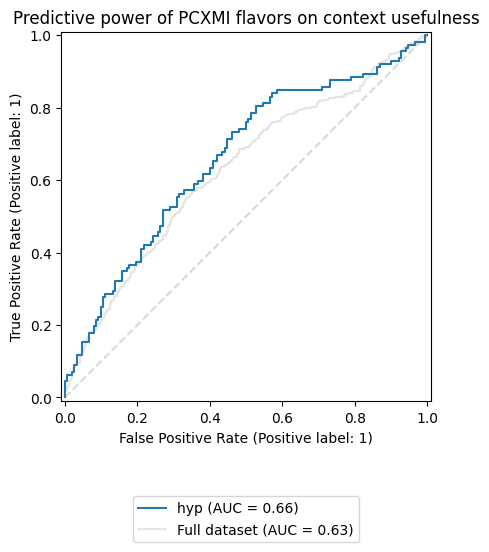

EN-PT-BR


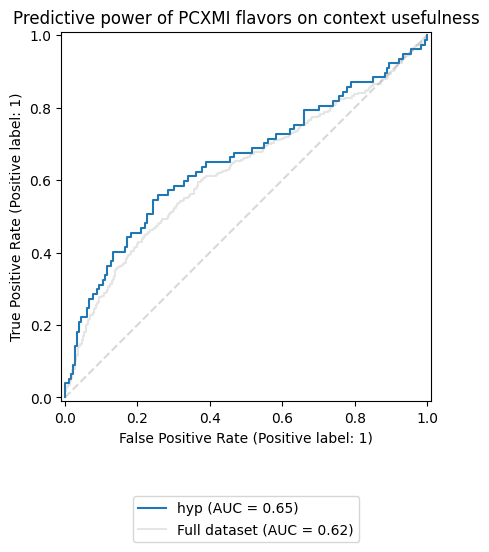

EN-KO


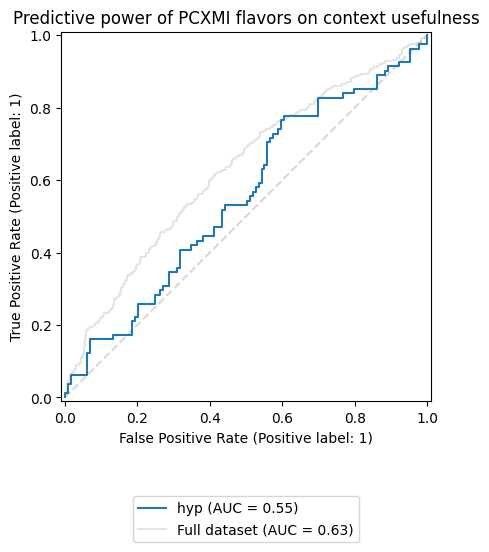

DE-EN


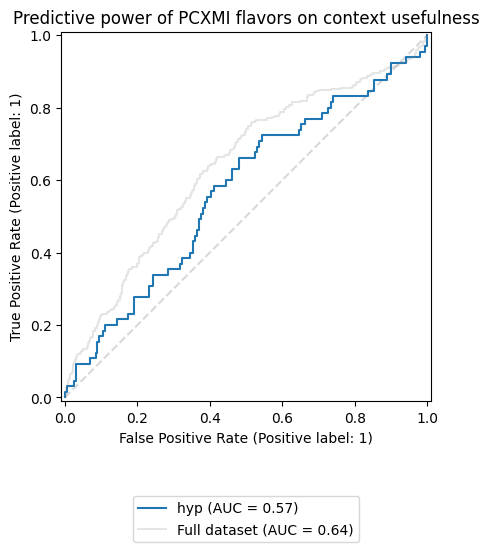

FR-EN


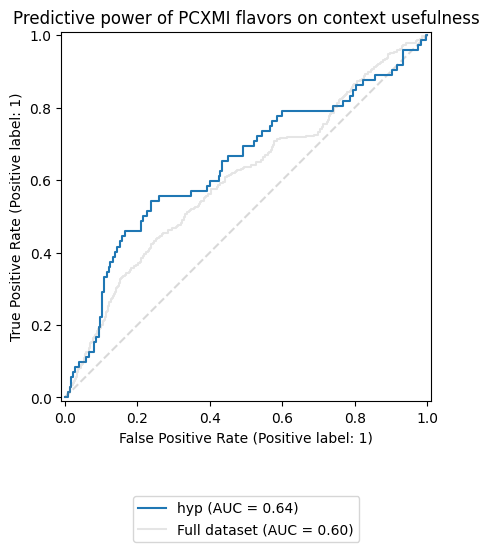

NL-EN


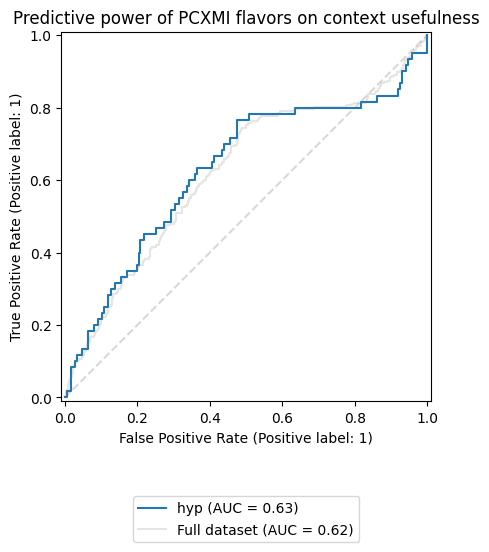

PT-BR-EN


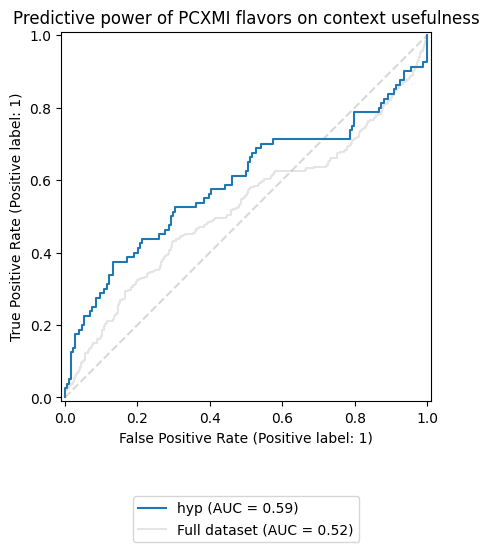

KO-EN


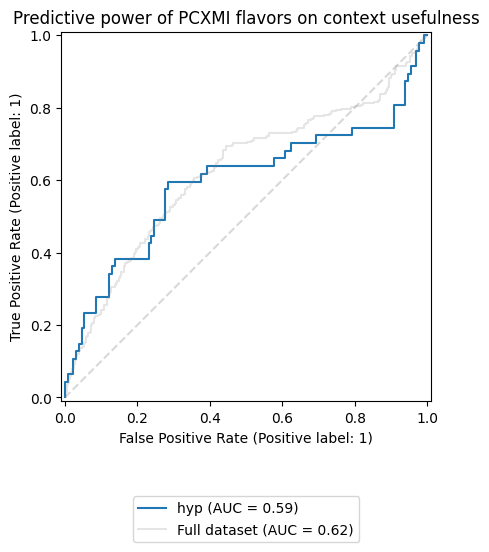

In [9]:
estimators = [
    "hyp",
]
quantile = 0.80
for lp in lps:
    df = make_df(dataset, lp, model, context_postfix, oracle_metric)
    df_subset = df[df["seg_id"] > df["seg_id"].quantile(quantile)]
    print(lp.upper())
    make_roc_plot_with_orig(df_subset, estimators, df)

### Earlier turns

EN-DE


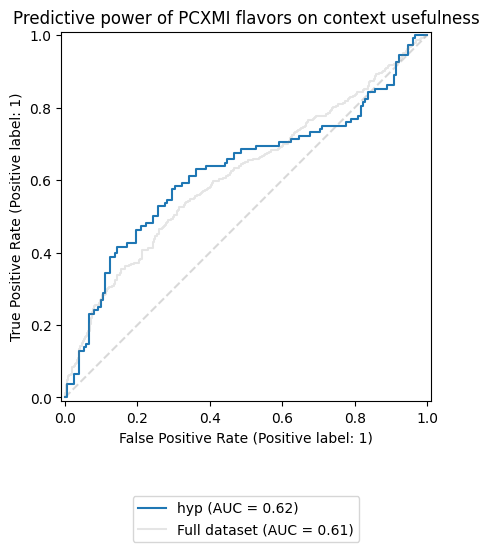

EN-FR


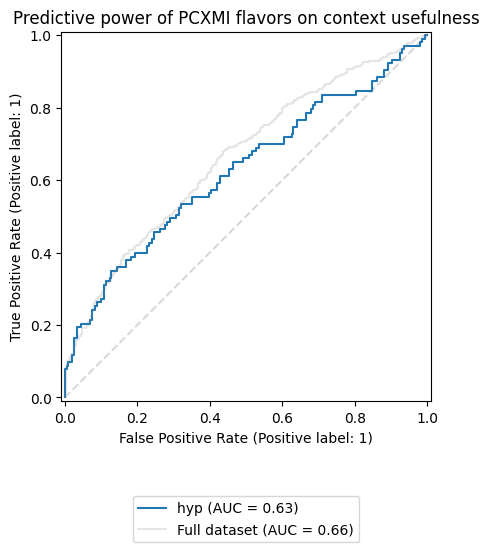

EN-NL


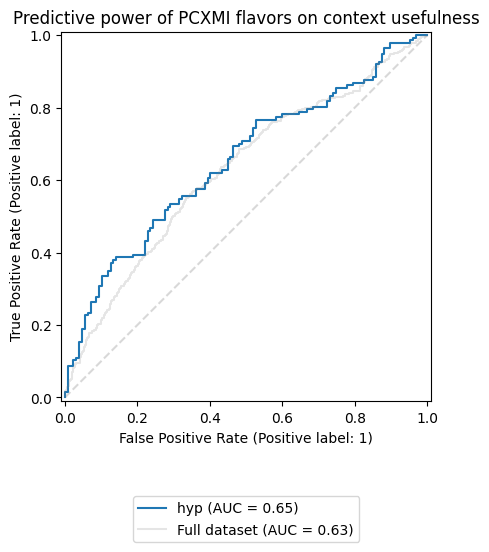

EN-PT-BR


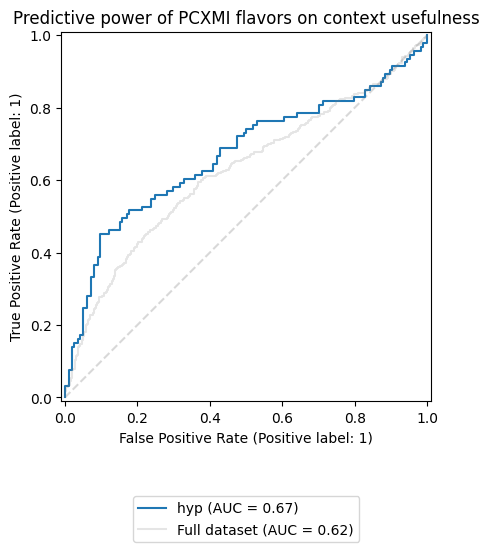

EN-KO


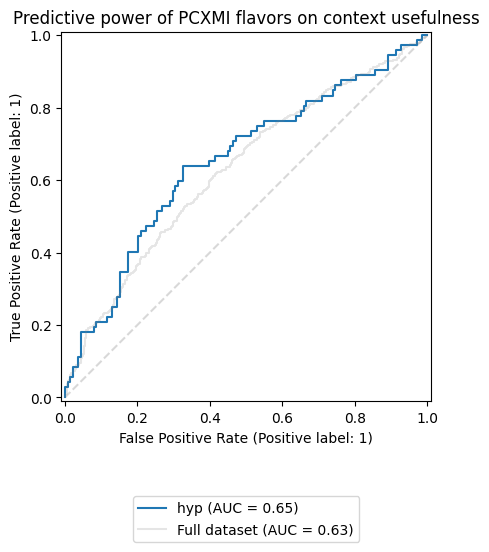

DE-EN


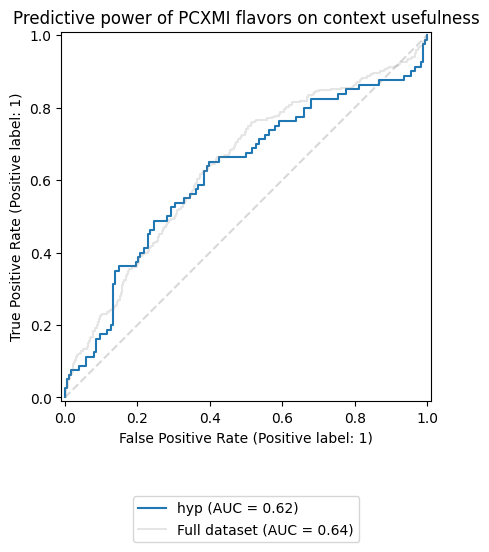

FR-EN


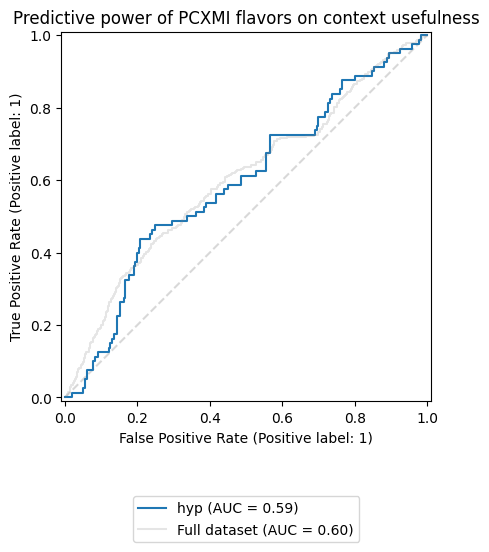

NL-EN


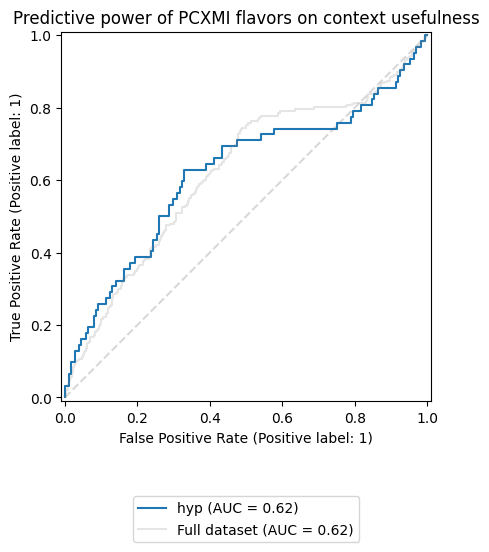

PT-BR-EN


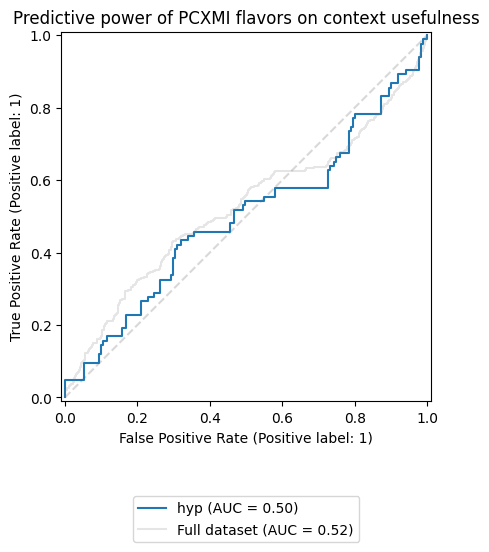

KO-EN


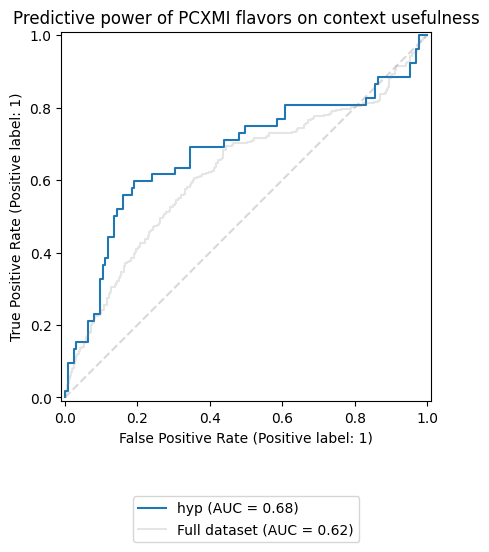

In [10]:
estimators = [
    "hyp",
]
quantile = 0.20
for lp in lps:
    df = make_df(dataset, lp, model, context_postfix, oracle_metric)
    df_subset = df[df["seg_id"] < df["seg_id"].quantile(quantile)]
    print(lp.upper())
    make_roc_plot_with_orig(df_subset, estimators, df)